In [6]:
#导入所需库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
#防止图片中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [7]:
#读取主数据集信息
DATA_PATH = 'D:/kiva-analysis/data/kiva_loans.csv'
FIG_DIR = 'D:/kiva-analysis/figures'
os.makedirs(FIG_DIR, exist_ok=True)

assert os.path.exists(DATA_PATH), f"数据文件不存在：{DATA_PATH}"
data = pd.read_csv(DATA_PATH)
print(f"✅ 数据读取成功：{len(data):,} 行")
data.head(10)
data.info()
data.describe()

✅ 数据读取成功：671,205 行
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  671205 non-null  int64  
 1   funded_amount       671205 non-null  float64
 2   loan_amount         671205 non-null  float64
 3   activity            671205 non-null  object 
 4   sector              671205 non-null  object 
 5   use                 666973 non-null  object 
 6   country_code        671197 non-null  object 
 7   country             671205 non-null  object 
 8   region              614405 non-null  object 
 9   currency            671205 non-null  object 
 10  partner_id          657698 non-null  float64
 11  posted_time         671205 non-null  object 
 12  disbursed_time      668809 non-null  object 
 13  funded_time         622874 non-null  object 
 14  term_in_months      671205 non-null  float64
 15  lender_count   

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count
count,6.712050e+05,671205.000000,671205.000000,657698.000000,671205.000000,671205.000000
mean,9.932486e+05,785.995061,842.397107,178.199616,13.739022,20.590922
std,1.966113e+05,1130.398941,1198.660073,94.247581,8.598919,28.459551
min,6.530470e+05,0.000000,25.000000,9.000000,1.000000,0.000000
25%,8.230720e+05,250.000000,275.000000,126.000000,8.000000,7.000000
50%,9.927800e+05,450.000000,500.000000,145.000000,13.000000,13.000000
75%,1.163653e+06,900.000000,1000.000000,204.000000,14.000000,24.000000
max,1.340339e+06,100000.000000,100000.000000,536.000000,158.000000,2986.000000


In [8]:
#检查数据集是否存在缺失值并处理
key_cols = ['country', 'sector', 'date', 'loan_amount', 'borrower_genders']
data = data.dropna(subset=key_cols)
print(f"清洗后：{len(data):,} 条（保留 {len(data)/671205:.1%}）")

清洗后：666,984 条（保留 99.4%）


In [9]:
#查看数据集的前10行数据
#主要贷款的国家，行业
print(data['country'].value_counts().head(10))
print("-"*30)
print(data['sector'].value_counts().head(10))

country
Philippines    160361
Kenya           75113
El Salvador     39321
Cambodia        34811
Pakistan        26853
Peru            22179
Colombia        21218
Uganda          20390
Tajikistan      19518
Ecuador         13487
Name: count, dtype: int64
------------------------------
sector
Agriculture       179224
Food              135749
Retail            123758
Services           44699
Personal Use       36247
Housing            33571
Clothing           32480
Education          30837
Transportation     15455
Arts               11994
Name: count, dtype: int64


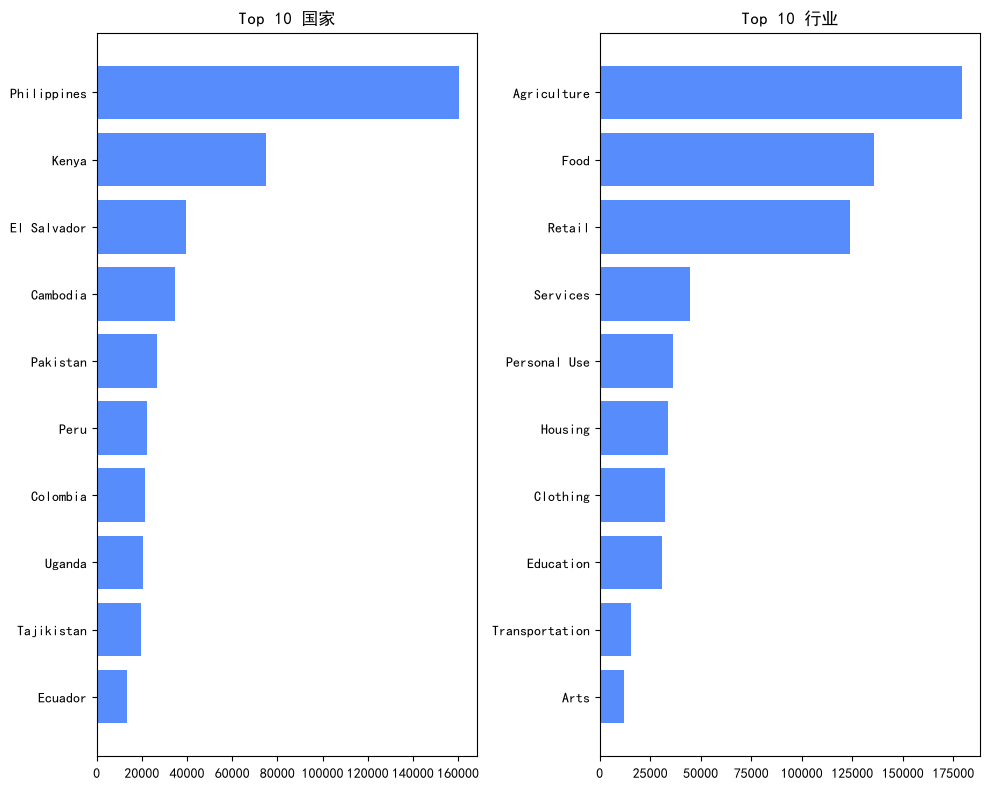

In [10]:
#TOP10 国家 行业
plt.figure(figsize=(10,8))
f1=plt.subplot(121)
f2=plt.subplot(122)
country = data['country'].value_counts().sort_values(ascending=False).head(10)
sector  = data['sector'].value_counts().sort_values(ascending=False).head(10)

f1.barh(country.index[::-1], country.values[::-1])
f2.barh(sector.index[::-1], sector.values[::-1])
f1.set_title("Top 10 国家")
f2.set_title("Top 10 行业")
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_country-sector_top10.png', dpi=300, bbox_inches='tight')

plt.show()


In [11]:
country = data['country'].value_counts().head(10)
print(country)
print("第一名占比：", country.iloc[0] / data.shape[0])
print(f"由此可知,{country.index[0]}是贷款的绝对主力")

country
Philippines    160361
Kenya           75113
El Salvador     39321
Cambodia        34811
Pakistan        26853
Peru            22179
Colombia        21218
Uganda          20390
Tajikistan      19518
Ecuador         13487
Name: count, dtype: int64
第一名占比： 0.24042705672100081
由此可知,Philippines是贷款的绝对主力


In [12]:
sector = data['sector'].value_counts()
print(sector)
print("前 3 行业占比：", sector.head(3).sum() / data.shape[0])
print(f"{','.join(sector.head(3).index)}三个行业占据绝对主力")

sector
Agriculture       179224
Food              135749
Retail            123758
Services           44699
Personal Use       36247
Housing            33571
Clothing           32480
Education          30837
Transportation     15455
Arts               11994
Health              9172
Construction        6194
Manufacturing       6158
Entertainment        820
Wholesale            626
Name: count, dtype: int64
前 3 行业占比： 0.6577833951039306
Agriculture,Food,Retail三个行业占据绝对主力


In [13]:
top=data.groupby(['country','sector']).size().sort_values(ascending=False).head(10)
print(f"交叉验证发现，{'的'.join(top.index[0])}是贷款主力")

交叉验证发现，Philippines的Retail是贷款主力


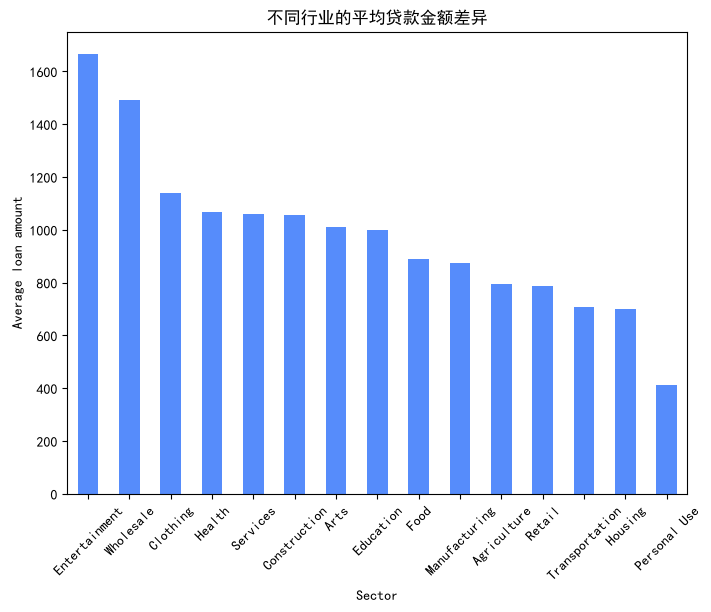

由图发现'Entertainment'行业的平均贷款金额最高


In [14]:
#不同行业平均贷款金额分析
sec=data.groupby('sector')['loan_amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,6))
sec.plot(kind='bar')
plt.title("不同行业的平均贷款金额差异")
plt.xlabel("Sector")
plt.ylabel("Average loan amount")
plt.xticks(rotation=45)
plt.savefig(f'{FIG_DIR}/02_different-sector_amount.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"由图发现'{sec.index[0]}'行业的平均贷款金额最高")

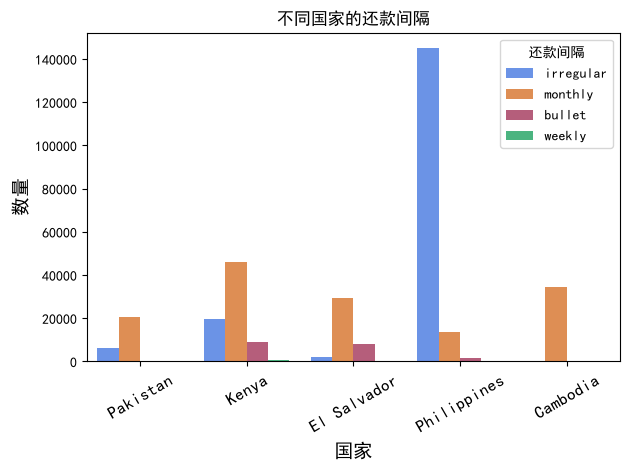

In [15]:
#不同国家还款间隔分析图
top5 = data['country'].value_counts().head(5).index  #获取top5国家
sub = data[data['country'].isin(top5)]  #筛选数据

sns.countplot(data=sub, x='country', hue='repayment_interval')
plt.title('不同国家的还款间隔')
plt.xticks(rotation=30,fontsize=12)
plt.legend(title='还款间隔')
plt.xlabel("国家",fontsize=14)
plt.ylabel("数量",fontsize=14)
plt.savefig(f'{FIG_DIR}/03_repayment_interval.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

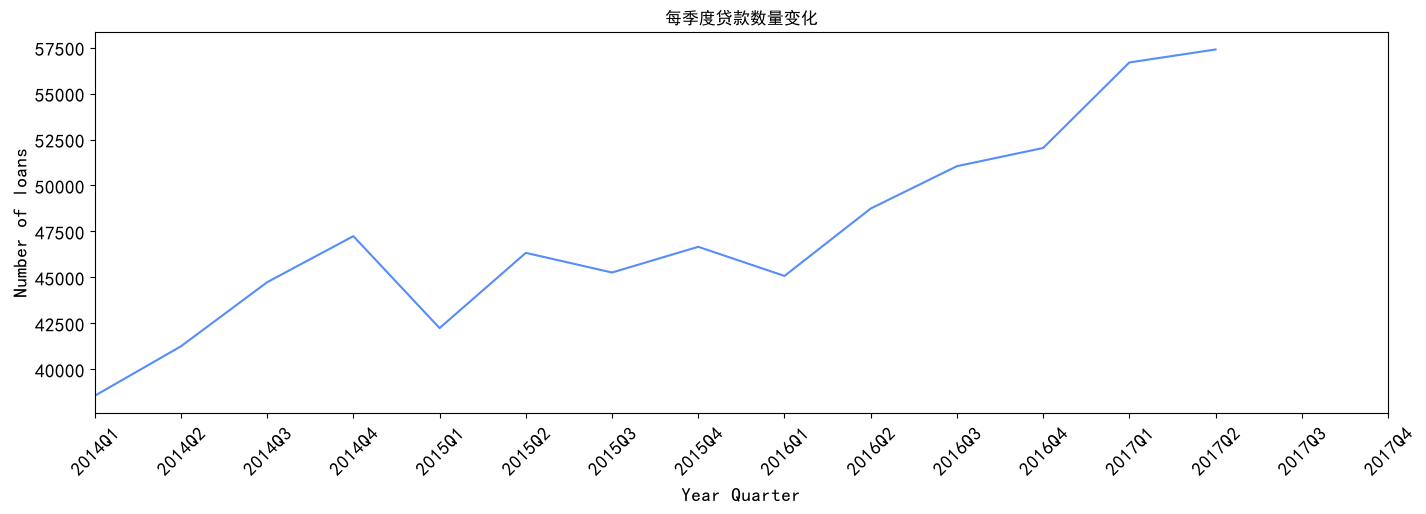

In [16]:
#季度还款变化分析
data['date'] = pd.to_datetime(data['date'])
data['year_month'] = data['date'].dt.to_period('Q')

quarterly = data.groupby('year_month').size()
quarterly = quarterly.iloc[0:14]
plt.figure(figsize=(14, 5))
quarterly.plot()
plt.xlabel("Year Quarter",fontsize=14)
plt.title("每季度贷款数量变化")
plt.ylabel("Number of loans",fontsize=14)
plt.tight_layout()
plt.xticks([f'{y}Q{q}' for y in range(2014, 2018) for q in range(1, 5)],
           [f'{y}Q{q}' for y in range(2014, 2018) for q in range(1, 5)],
           rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f'{FIG_DIR}/04_quarterly_loans.png', dpi=300, bbox_inches='tight')

plt.show()

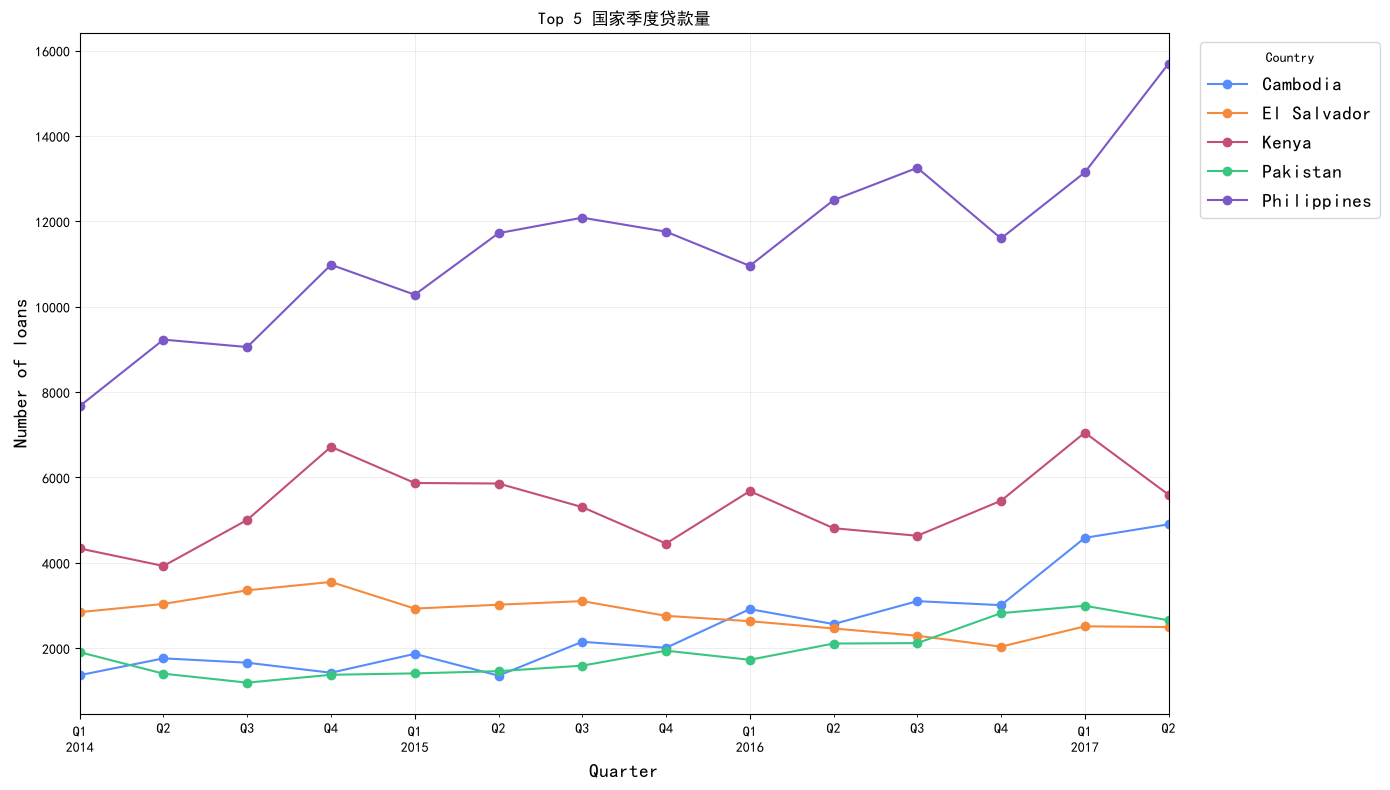

整体来看，Philippines的贷款数量最多,峰值在2017Q2，数量为15695
------------------------------
各国峰值季度:
country
Cambodia       2017Q2
El Salvador    2014Q4
Kenya          2017Q1
Pakistan       2017Q1
Philippines    2017Q2
dtype: period[Q-DEC]
------------------------------

整体增长率:
country
Cambodia        2.58%
Philippines     1.05%
Pakistan        0.39%
Kenya           0.29%
El Salvador    -0.12%
dtype: object
------------------------------

各个国家在贷款总量中的占比:
country
Philippines    47.74%
Kenya          22.29%
El Salvador    11.65%
Cambodia       10.35%
Pakistan        7.97%
dtype: object


In [17]:
#时间*国家

#数据处理
data['date']=pd.to_datetime(data['date'])
data['quarter']=data['date'].dt.to_period('Q')
top5=data['country'].value_counts().head(5).index
sub=data[data['country'].isin(top5)]

#准备作图
pivot=sub.groupby(['quarter','country']).size().unstack().fillna(0)
pivot=pivot.iloc[:-1]

#作图
plt.figure(figsize=(14,8))
pivot.plot(ax=plt.gca(),marker='o')
plt.title("Top 5 国家季度贷款量")
plt.xlabel("Quarter",fontsize=14)
plt.ylabel("Number of loans",fontsize=14)
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_top5_countries_quarterly_loans.png', dpi=300, bbox_inches='tight')

plt.show()

#总结
print(f'整体来看，{pivot.sum(axis=0).idxmax()}的贷款数量最多,峰值在{pivot.idxmax(axis=0).max()}，数量为{pivot.max().max()}')
print("-"*30)
#各国峰值
peak = pivot.idxmax(axis=0)
print("各国峰值季度:")
print(peak)
print("-"*30)
#每个国家的"整体增长率"（首季 vs 末季）
growth = pivot.iloc[-1] / pivot.iloc[0] - 1
print("\n整体增长率:")
print(growth.sort_values(ascending=False).map(lambda x: f'{x:.2f}%'))
print("-"*30)
#各个国家在贷款总量中的占比
country_share = pivot.sum() / pivot.sum().sum()
print("\n各个国家在贷款总量中的占比:")
print(country_share.sort_values(ascending=False).map(lambda x: f'{x:.2%}'))

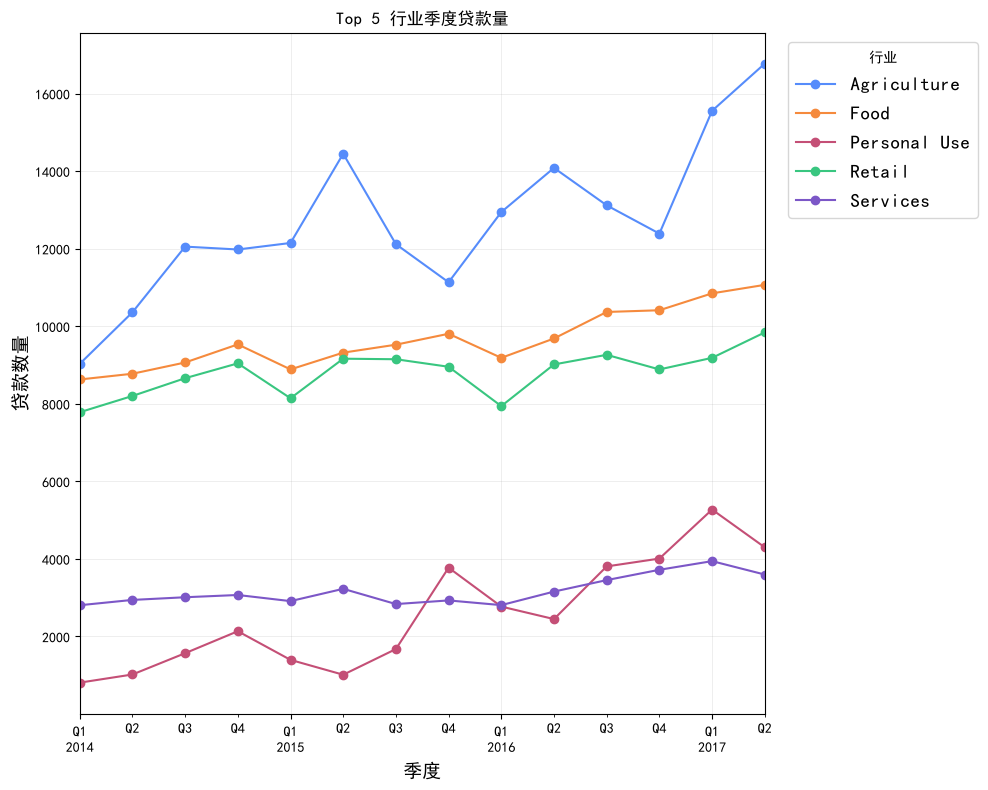


各行业总贷款量:
sector
Agriculture     178124
Food            135099
Retail          123227
Services         44419
Personal Use     36004
dtype: int64
------------------------------
各行业贷款峰值季度
sector
Agriculture     2017Q2
Food            2017Q2
Personal Use    2017Q1
Retail          2017Q2
Services        2017Q1
dtype: period[Q-DEC]


In [18]:
#行业*季度
#数据处理
top5=data['sector'].value_counts().head(5).index
sub=data[data['sector'].isin(top5)]

#准备作图
pivot=sub.groupby(['quarter','sector']).size().unstack().fillna(0)
pivot=pivot.iloc[:-1]
#作图
plt.figure(figsize=(10,8))
pivot.plot(ax=plt.gca(),marker='o')
plt.title("Top 5 行业季度贷款量")
plt.xlabel("季度",fontsize=14)
plt.ylabel("贷款数量",fontsize=14)
plt.legend(title='行业', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_top5_sectors_quarterly_loans.png', dpi=300, bbox_inches='tight')

plt.show()

#总结
print("\n各行业总贷款量:")
print(pivot.sum().sort_values(ascending=False))
print("-"*30)
print('各行业贷款峰值季度')
print(pivot.idxmax())


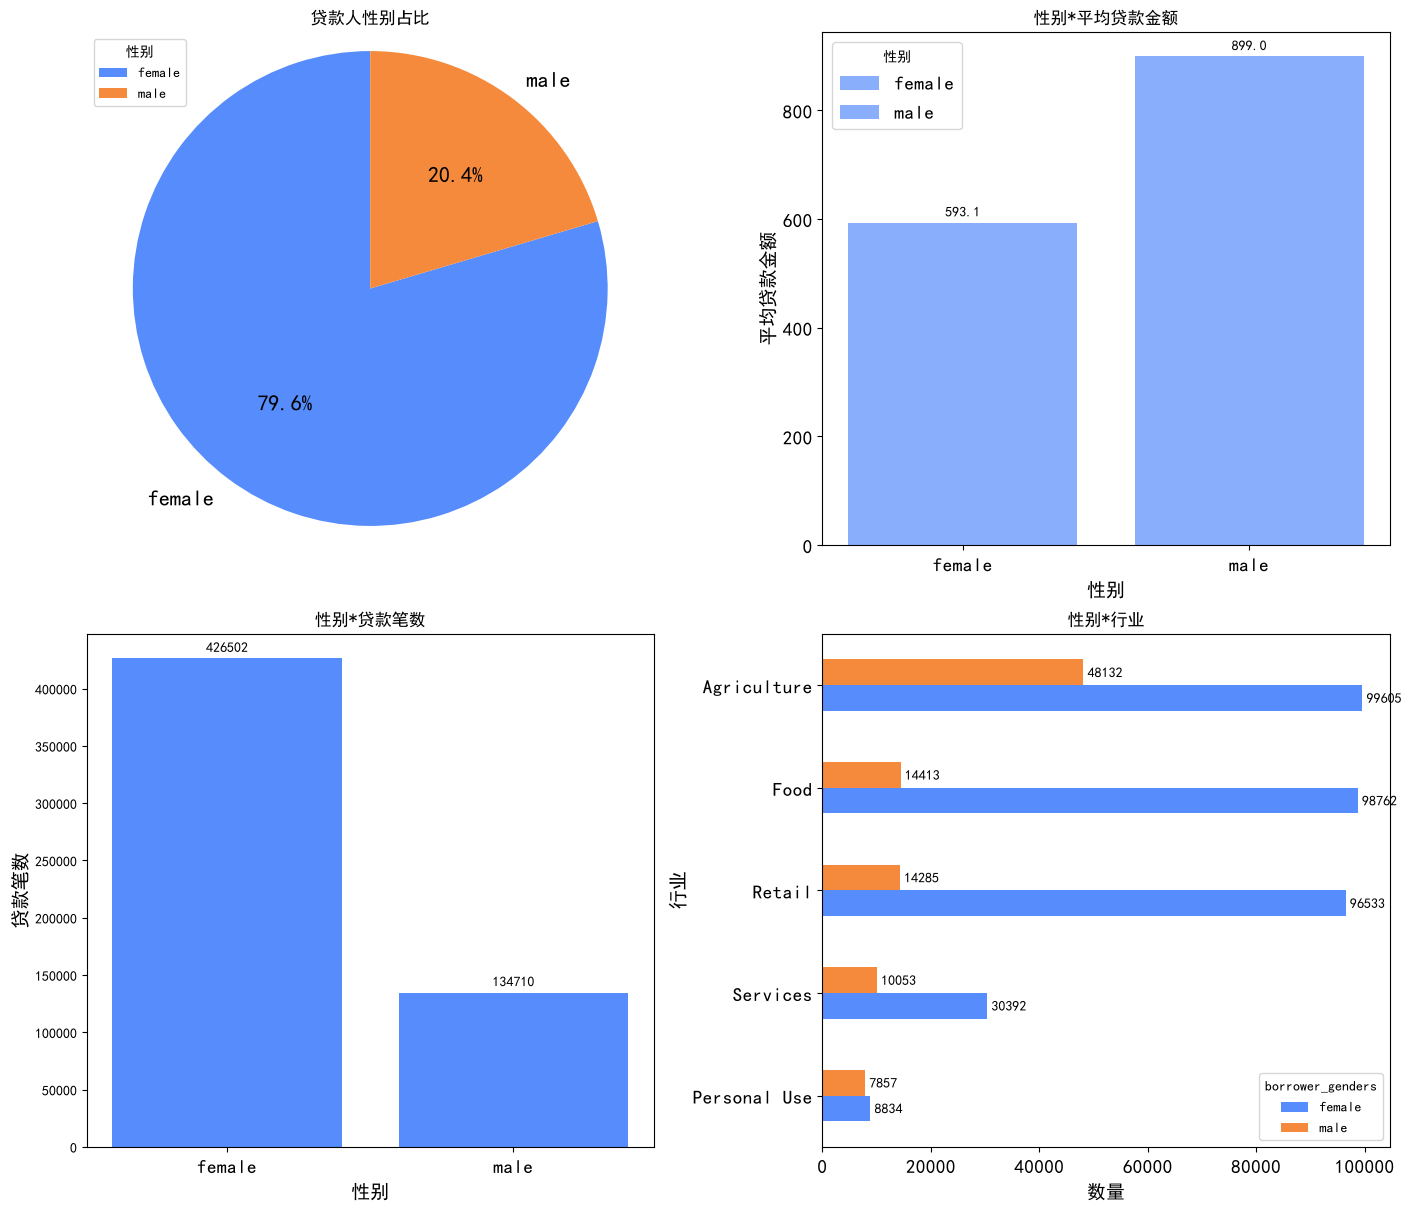

In [19]:
#借款人性别分析
gender_list=[]
for i in data['borrower_genders']:
    gender_list.extend(x.strip() for x in str(i).split(','))
gender_counts=pd.Series(gender_list).value_counts()

fig, axes=plt.subplots(2,2,figsize=(14,12),constrained_layout=True)
# 借款人性别占比
axes[0,0].pie(gender_counts.values,labels=gender_counts.index,autopct='%1.1f%%',startangle=90,textprops={'fontsize': 16})
axes[0,0].set_title('借款人性别占比')
axes[0,0].axis('equal')
axes[0,0].legend(gender_counts.index,title='性别')
plt.savefig(f'{FIG_DIR}/07_gender_distribution.png', dpi=300, bbox_inches='tight')
#性别*平均贷款金额
gender_single=data[data['borrower_genders'].isin(['male','female'])]
avg=gender_single.groupby('borrower_genders')['loan_amount'].mean()
axes[0,1].bar(avg.index,avg.values,alpha=0.7,label=avg.index)
axes[0,1].set_title('性别*平均借款金额')
axes[0,1].set_xlabel('性别',fontsize=14)
axes[0,1].set_ylabel('平均借款金额',fontsize=14)
axes[0,1].legend(avg.index, title='性别', fontsize=14)
axes[0,1].tick_params(axis='x', labelsize=14)
axes[0,1].tick_params(axis='y', labelsize=14)
axes[0,1].bar_label(axes[0,1].containers[0], fmt='%.1f', padding=3)
plt.savefig(f'{FIG_DIR}/08_gender_loan_amount.png', dpi=300, bbox_inches='tight')
#性别*贷款笔数
avg_amount=gender_single.groupby('borrower_genders').size()
axes[1,0].bar(avg_amount.index,avg_amount.values,align='center')
axes[1,0].set_title('性别*借款笔数')
axes[1,0].set_xlabel('性别',fontsize=14)
axes[1,0].set_ylabel('借款笔数',fontsize=14)
axes[1,0].tick_params(axis='x', labelsize=14)
axes[1,0].bar_label(axes[1,0].containers[0], fmt='%.0f', padding=3)
plt.savefig(f'{FIG_DIR}/09_gender_loan_count.png', dpi=300, bbox_inches='tight')

#性别*行业
top5_sectors=data['sector'].value_counts().head(5).index
sex_sector=gender_single[gender_single['sector'].isin(top5_sectors)]
pivot=pd.crosstab(sex_sector['sector'],sex_sector['borrower_genders'])
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=True).drop(columns='total')
pivot.plot(kind='barh',ax=axes[1,1])
axes[1,1].set_title('性别*行业')
axes[1,1].set_xlabel('数量',fontsize=14)
axes[1,1].set_ylabel('行业',fontsize=14)
axes[1,1].tick_params(axis='x', labelsize=14)
axes[1,1].tick_params(axis='y', labelsize=14)
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt='%.0f', padding=3)
plt.savefig(f'{FIG_DIR}/10_gender_sector.png', dpi=300, bbox_inches='tight')


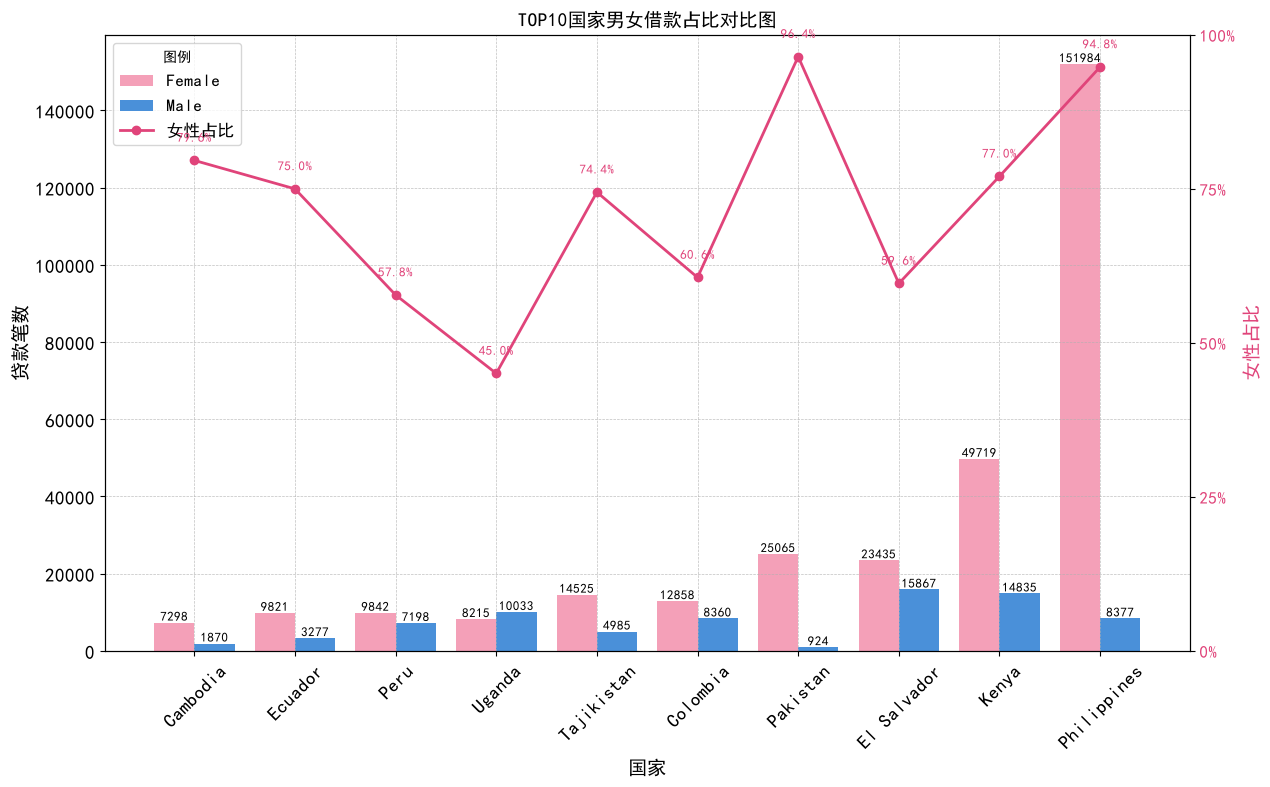

In [20]:
#性别*国家
gender_country = data[data['borrower_genders'].isin(['female', 'male'])]
top10_countries=data['country'].value_counts().head(10).index
gender_country_top10 = gender_country[gender_country['country'].isin(top10_countries)]

pivot=pd.crosstab(gender_country_top10['country'],gender_country_top10['borrower_genders'])
pivot['total']=pivot.sum(axis=1)
pivot=pivot.sort_values('total',ascending=True).drop(columns='total')

fig,ax=plt.subplots(figsize=(14,8))
x=range(len(pivot))
width=0.4
ax.bar([i - width/2 for i in x], pivot['female'], width, label='Female',color='#f4a0b8')
ax.bar([i + width/2 for i in x], pivot['male'], width, label='Male',color='#4a90d9')
ax.set_xlabel('国家', fontsize=14)
ax.set_ylabel('贷款笔数', fontsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45)
ax.grid(linestyle='--', alpha=0.8, linewidth=0.5)
for i, (f, m) in enumerate(zip(pivot['female'], pivot['male'])):
    ax.text(i - width/2, f, f'{f:}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, m, f'{m:}', ha='center', va='bottom', fontsize=9)

ratio = (pivot['female'] / (pivot['female'] + pivot['male'])).values
ax2 = ax.twinx()
ax2.plot(x, ratio, color='#e0447a', marker='o', linewidth=2, label='女性占比')
ax2.set_ylabel('女性占比', fontsize=14, color='#e0447a')
ax2.tick_params(axis='y', labelcolor='#e0447a', labelsize=12)
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax2.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
for i, v in enumerate(ratio):
    ax2.text(i, v + 0.03, f'{v:.1%}', ha='center', fontsize=9, color='#e0447a')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, title='图例', loc='best', fontsize=12)
plt.title('TOP10国家男女借款占比对比图', fontsize=14)
plt.savefig(f'{FIG_DIR}/11_gender_country.png', dpi=300, bbox_inches='tight')
plt.show()


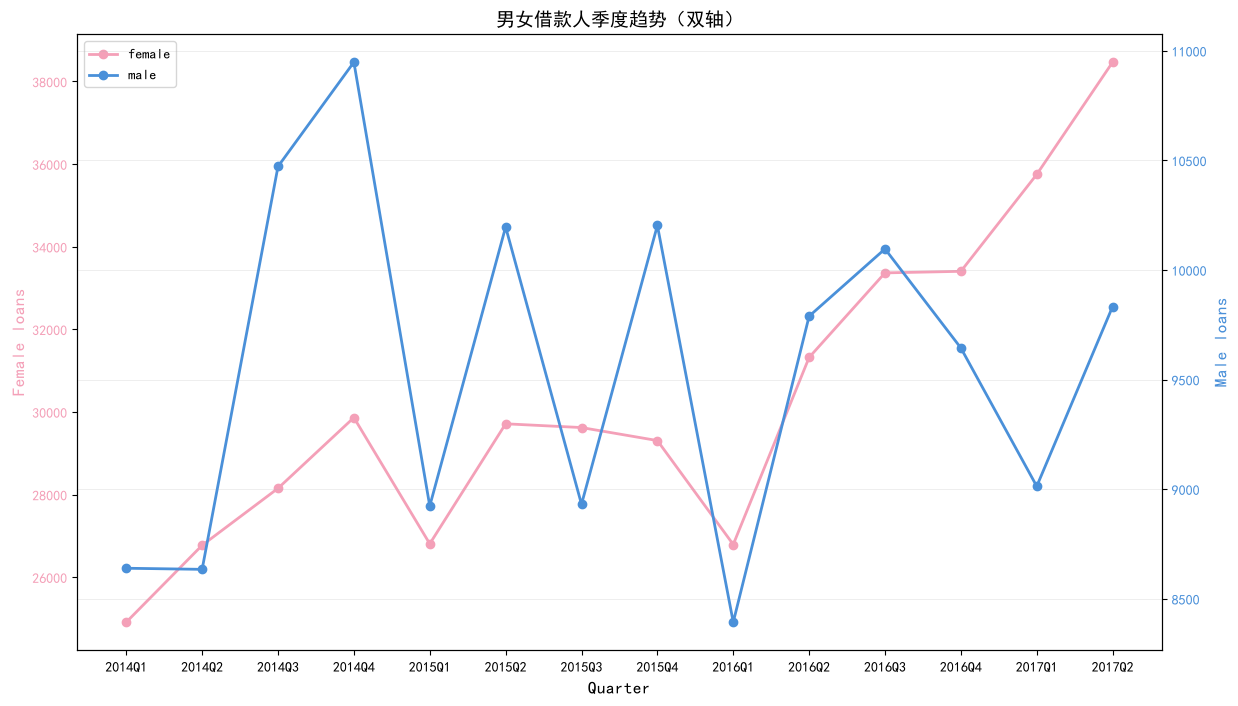

In [21]:
#性别*时间
#1.数据处理
data['quarter']=pd.to_datetime(data['date']).dt.to_period('Q')
sub=data[data['borrower_genders'].isin(['female','male'])]
quarterly=pd.crosstab(sub['quarter'],sub['borrower_genders'])
quarterly=quarterly.iloc[:-1]
fig, ax1 = plt.subplots(figsize=(14, 8))
ax1.plot(quarterly.index.astype(str),quarterly['female'],marker='o',color='#f4a0b8',label='female',linewidth=2)
ax1.set_ylabel('Female loans', color='#f4a0b8', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#f4a0b8')

ax2=ax1.twinx()
ax2.plot(quarterly.index.astype(str),quarterly['male'],marker='o',color='#4a90d9',label='male',linewidth=2)
ax2.set_ylabel('Male loans', color='#4a90d9', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#4a90d9')

plt.title("男女借款人季度趋势（双轴）", fontsize=14)
ax1.set_xlabel("Quarter", fontsize=12)
plt.xticks(rotation=90)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.grid(alpha=0.3)
plt.savefig(f'{FIG_DIR}/12_gender_quarterly.png', dpi=300, bbox_inches='tight')

plt.show()


女性首季借款数量：24911,末季借款数量：38467.
男性首季借款数量：8639,末季借款数量：9833.
女性借款数量增长倍数：1.5倍
男性借款数量增长倍数：1.1倍
整体女性借款占比：76.0%
整体男性借款占比：24.0%
女性首季占比:74.25%
女性末季占比:79.64%
女性占比 - 最低: 72.89%
女性占比 - 最高: 79.87%
女性占比 - 波动幅度: 6.98%
男性首季占比:25.75%
男性末季占比:20.36%
男性占比 - 最低: 20.13%
男性占比 - 最高: 27.11%
男性占比 - 波动幅度: 6.98%


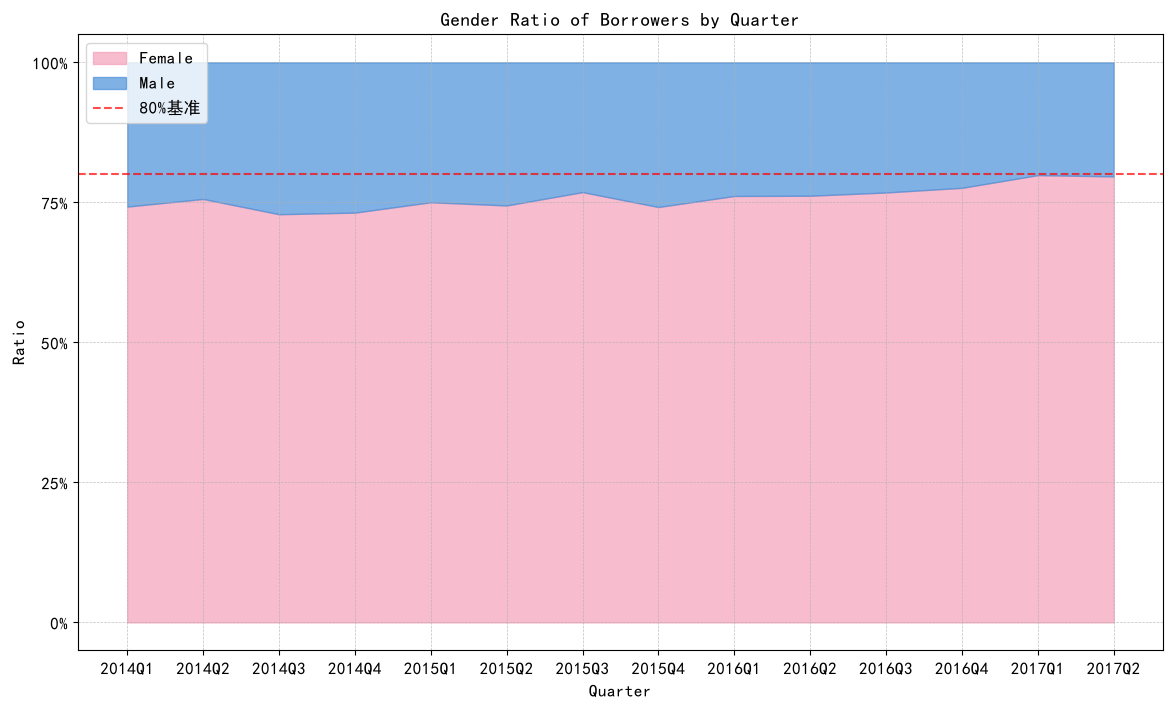

In [22]:
#借款数量
print(f"女性首季借款数量：{quarterly['female'].iloc[0]},末季借款数量：{quarterly['female'].iloc[-1]}.")
print(f"男性首季借款数量：{quarterly['male'].iloc[0]},末季借款数量：{quarterly['male'].iloc[-1]}.")
#增长倍数
female_growth=quarterly['female'].iloc[-1]/quarterly['female'].iloc[0]
male_growth=quarterly['male'].iloc[-1]/quarterly['male'].iloc[0]
print(f"女性借款数量增长倍数：{female_growth:.1f}倍")
print(f"男性借款数量增长倍数：{male_growth:.1f}倍")
#占比
total_female = quarterly['female'].sum()
total_male   = quarterly['male'].sum()
total = total_female + total_male

print(f"整体女性借款占比：{total_female/total:.1%}")
print(f"整体男性借款占比：{total_male/total:.1%}")

female_ratio=quarterly['female']/quarterly.sum(axis=1)
male_ratio=quarterly['male']/quarterly.sum(axis=1)

print(f"女性首季占比:{female_ratio.iloc[0]:.2%}")
print(f"女性末季占比:{female_ratio.iloc[-1]:.2%}")
print("女性占比 - 最低:", f"{female_ratio.min():.2%}")
print("女性占比 - 最高:", f"{female_ratio.max():.2%}")
print("女性占比 - 波动幅度:", f"{(female_ratio.max() - female_ratio.min()):.2%}")
print(f"男性首季占比:{male_ratio.iloc[0]:.2%}")
print(f"男性末季占比:{male_ratio.iloc[-1]:.2%}")
print("男性占比 - 最低:", f"{male_ratio.min():.2%}")
print("男性占比 - 最高:", f"{male_ratio.max():.2%}")
print("男性占比 - 波动幅度:", f"{(male_ratio.max() - male_ratio.min()):.2%}")

#图例
fig,ax=plt.subplots(figsize=(14,8))
x=range(len(female_ratio))

ax.fill_between(x, 0, female_ratio,
                color='#f4a0b8', alpha=0.7, label='Female')

ax.fill_between(x, female_ratio, 1,
                color='#4a90d9', alpha=0.7, label='Male')
ax.set_xticks(x)
ax.set_xticklabels(female_ratio.index.astype(str), rotation=0)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.axhline(0.8, color='r', alpha=0.7, linestyle='--',label='80%基准')
ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Ratio', fontsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(loc='upper left', fontsize=12)
ax.grid(linestyle='--', alpha=0.8, linewidth=0.5)
plt.title('Gender Ratio of Borrowers by Quarter', fontsize=14)
plt.savefig(f'{FIG_DIR}/13_gender_ratio.png', dpi=300, bbox_inches='tight')
plt.show()


In [23]:
# 报告
print("=" * 60)
print("Kiva 小额信贷数据分析 —— 报告摘要")
print("=" * 60)

# ---------- 1. 数据概览 ----------
n_records = len(data)
n_countries = data['country'].nunique()
n_sectors = data['sector'].nunique()
date_min = data['date'].min().date()
date_max = data['date'].max().date()

print(f"\n【一、数据概览】")
print(f"记录数：{n_records:,} 条")
print(f"覆盖国家：{n_countries} 个")
print(f"覆盖行业：{n_sectors} 个")
print(f"时间跨度：{date_min} ~ {date_max}")
print(f"→ 解读：数据集包含 {n_records:,} 条贷款记录，"
      f"覆盖 {n_countries} 个国家和 {n_sectors} 个行业，"
      f"时间跨度 {date_min} ~ {date_max}。")

# ---------- 2. 国家维度 ----------
country_counts = data['country'].value_counts()
top5_countries = country_counts.head(5).index.tolist()
top1_country = top5_countries[0]
top1_share = country_counts.iloc[0] / n_records
top5_share = country_counts.head(5).sum() / n_records

print(f"\n【二、国家维度】")
print(f"Top 5 国家：{', '.join(top5_countries)}")
print(f"领跑国家：{top1_country}（占比 {top1_share:.2%}）")
print(f"Top 5 合计占比：{top5_share:.2%}")
print(f"→ 解读：Kiva 国家集中度较高，Top 5 国家占据 {top5_share:.2%} 的贷款量，"
      f"其中 {top1_country} 单国占比 {top1_share:.2%}，是绝对主力市场。")

# ---------- 3. 行业维度 ----------
sector_counts = data['sector'].value_counts()
top5_sectors = sector_counts.head(5).index.tolist()
top1_sector = top5_sectors[0]
top1_sector_share = sector_counts.iloc[0] / n_records
top5_sector_share = sector_counts.head(5).sum() / n_records

print(f"\n【三、行业维度】")
print(f"Top 5 行业：{', '.join(top5_sectors)}")
print(f"领跑行业：{top1_sector}（占比 {top1_sector_share:.2%}）")
print(f"Top 5 合计占比：{top5_sector_share:.2%}")
print(f"→ 解读：行业集中度极高，Top 5 行业占据 {top5_sector_share:.2%} 的贷款量，"
      f"其中 {top1_sector} 单行业占比 {top1_sector_share:.2%}，"
      f"说明 Kiva 的资金主要支持农业与生活类小微生意，符合普惠金融定位。")

# ---------- 4. 时间维度 ----------
q = data.groupby('quarter').size()
q_clean = q.iloc[1:-1]          # 剔除首尾残缺季度
growth = q_clean.iloc[-1] / q_clean.iloc[0]
cv = q_clean.std() / q_clean.mean()
mom = q_clean.pct_change()

print(f"\n【四、时间维度】")
print(f"时间区间：{q_clean.index[0]} ~ {q_clean.index[-1]}")
print(f"首季 {q_clean.iloc[0]:,} 笔 → 末季 {q_clean.iloc[-1]:,} 笔，"
      f"增长 {growth:.2f} 倍")
print(f"峰值 {q_clean.idxmax()}（{q_clean.max():,} 笔），"
      f"低谷 {q_clean.idxmin()}（{q_clean.min():,} 笔）")
print(f"波动系数 {cv:.1%}，"
      f"{'波动较大' if cv > 0.5 else '增长相对平稳'}")
print(f"环比增长最快：{mom.idxmax()}（+{mom.max():.1%}）")
print(f"环比下跌最快：{mom.idxmin()}（{mom.min():.1%}）")
print(f"→ 解读：Kiva 在约 3 年时间里，季度贷款量从 {q_clean.iloc[0]:,} 笔"
      f"增长到 {q_clean.iloc[-1]:,} 笔（{growth:.2f} 倍），"
      f"整体呈持续上升趋势，处于扩张期。")
# ---------- 5. 性别维度 ----------
#只统计单人借款
gender_single = data[data['borrower_genders'].isin(['female', 'male'])]
gender_cnt = gender_single['borrower_genders'].value_counts()
n_gender_total = gender_cnt.sum()
female_share = gender_cnt.get('female', 0) / n_gender_total
male_share   = gender_cnt.get('male', 0) / n_gender_total

# 平均 / 中位金额
gender_amount = gender_single.groupby('borrower_genders')['loan_amount'].agg(
    mean_amount='mean',
    median_amount='median',
    count='count'
)

# 时间趋势
gender_quarter = (data[data['borrower_genders'].isin(['female', 'male'])]
                  .groupby(['quarter', 'borrower_genders'])
                  .size()
                  .unstack()
                  .fillna(0))
gender_quarter = gender_quarter.iloc[:-1]     # 剔除最后一个残缺季
female_ratio_q = gender_quarter['female'] / gender_quarter.sum(axis=1)

print(f"\n【五、性别维度】")
print(f"单人借款记录数：{n_gender_total:,} 条")
print(f"女性借款占比：{female_share:.2%}    男性借款占比：{male_share:.2%}")
print(f"女性平均贷款金额：{gender_amount.loc['female', 'mean_amount']:.1f}"
      f"    男性平均贷款金额：{gender_amount.loc['male', 'mean_amount']:.1f}")
print(f"女性中位贷款金额：{gender_amount.loc['female', 'median_amount']:.1f}"
      f"    男性中位贷款金额：{gender_amount.loc['male', 'median_amount']:.1f}")
print(f"女性占比区间：{female_ratio_q.min():.2%} ~ {female_ratio_q.max():.2%}"
      f"（波动幅度 {female_ratio_q.max() - female_ratio_q.min():.2%}）")
print(f"→ 解读：Kiva 借款人以女性为主（占比约 {female_share:.0%}），"
      f"且女性平均贷款金额略{'高于' if gender_amount.loc['female','mean_amount'] > gender_amount.loc['male','mean_amount'] else '低于'}男性，"
      f"体现 Kiva 对女性创业者的重点支持。")

Kiva 小额信贷数据分析 —— 报告摘要

【一、数据概览】
记录数：666,984 条
覆盖国家：87 个
覆盖行业：15 个
时间跨度：2014-01-01 ~ 2017-07-26
→ 解读：数据集包含 666,984 条贷款记录，覆盖 87 个国家和 15 个行业，时间跨度 2014-01-01 ~ 2017-07-26。

【二、国家维度】
Top 5 国家：Philippines, Kenya, El Salvador, Cambodia, Pakistan
领跑国家：Philippines（占比 24.04%）
Top 5 合计占比：50.44%
→ 解读：Kiva 国家集中度较高，Top 5 国家占据 50.44% 的贷款量，其中 Philippines 单国占比 24.04%，是绝对主力市场。

【三、行业维度】
Top 5 行业：Agriculture, Food, Retail, Services, Personal Use
领跑行业：Agriculture（占比 26.87%）
Top 5 合计占比：77.91%
→ 解读：行业集中度极高，Top 5 行业占据 77.91% 的贷款量，其中 Agriculture 单行业占比 26.87%，说明 Kiva 的资金主要支持农业与生活类小微生意，符合普惠金融定位。

【四、时间维度】
时间区间：2014Q2 ~ 2017Q2
首季 41,249 笔 → 末季 57,398 笔，增长 1.39 倍
峰值 2017Q2（57,398 笔），低谷 2014Q2（41,249 笔）
波动系数 10.4%，增长相对平稳
环比增长最快：2015Q2（+9.7%）
环比下跌最快：2015Q1（-10.6%）
→ 解读：Kiva 在约 3 年时间里，季度贷款量从 41,249 笔增长到 57,398 笔（1.39 倍），整体呈持续上升趋势，处于扩张期。

【五、性别维度】
单人借款记录数：561,212 条
女性借款占比：76.00%    男性借款占比：24.00%
女性平均贷款金额：593.1    男性平均贷款金额：899.0
女性中位贷款金额：400.0    男性中位贷款金额：600.0
女性占比区间：72.89% ~ 79.87%（波动幅度 6.98%）
→ 解读：Kiva 借款人以女性为主（占比约

In [24]:
# ============================================================
# 总结与建议
# ============================================================
print("\n" + "=" * 60)
print("【六、总结与建议】")
print("=" * 60)

advice = f"""
1. 国家高度集中：Top 5 国家占 {top5_share:.2%}，
   其中 {top1_country} 占 {top1_share:.2%}，属于核心市场，建议重点维护。

2. 行业高度集中：Top 5 行业占 {top5_sector_share:.2%}，
   {top1_sector}（{top1_sector_share:.2%}）是绝对主力，
   说明 Kiva 的核心价值是支持农业与小微创业。

3. 时间持续增长：季度贷款量从 {q_clean.iloc[0]:,} 笔
   增长到 {q_clean.iloc[-1]:,} 笔（{growth:.2f} 倍），
   平台处于持续扩张期。

4. 性别差异明显：单人借款中女性占比 {female_share:.2%}，
   女性平均金额 {gender_amount.loc['female', 'mean_amount']:.0f}，
   男性平均金额 {gender_amount.loc['male', 'mean_amount']:.0f}，
   平台呈现出以女性为主的普惠金融特征。

5. 数据边界提示：数据截止 {date_max}，
   如需分析近 3 年趋势需补充 2017 年之后的数据。
"""
print(advice)

print("-" * 60)
print("核心结论（一句话）：")
print(f"Kiva 是一家『国家集中（{top1_country}为核） + 行业集中（{top1_sector}为首）"
      f" + 女性主导（{female_share:.0%}） + 持续增长』的普惠金融平台。")
print("=" * 60)


【六、总结与建议】

1. 国家高度集中：Top 5 国家占 50.44%，
   其中 Philippines 占 24.04%，属于核心市场，建议重点维护。

2. 行业高度集中：Top 5 行业占 77.91%，
   Agriculture（26.87%）是绝对主力，
   说明 Kiva 的核心价值是支持农业与小微创业。

3. 时间持续增长：季度贷款量从 41,249 笔
   增长到 57,398 笔（1.39 倍），
   平台处于持续扩张期。

4. 性别差异明显：单人借款中女性占比 76.00%，
   女性平均金额 593，
   男性平均金额 899，
   平台呈现出以女性为主的普惠金融特征。

5. 数据边界提示：数据截止 2017-07-26，
   如需分析近 3 年趋势需补充 2017 年之后的数据。

------------------------------------------------------------
核心结论（一句话）：
Kiva 是一家『国家集中（Philippines为核） + 行业集中（Agriculture为首） + 女性主导（76%） + 持续增长』的普惠金融平台。
